# Predicting Heart Disease

Goal - Predict the likelihood of heart disease.

- Age  -                     Age of the patient (in years)
- Sex   -                    Gender of the patient (1 = Male, 0 = Female)
- Chest pain type -          Type of chest pain:1 = Typical angina, 2 = Atypical angina, 3 = Non-anginal pain, 4 = Asymptomatic
- BP   -                     Resting blood pressure (mm Hg)
- Cholesterol  -             Serum cholesterol level (mg/dL)
- FBS over 120  -            Fasting blood sugar > 120 mg/dL (1 = True, 0 = False)
- EKG results  -             Resting electrocardiogram results:0 = Normal, 1 = ST-T wave abnormality, 2 = Left ventricular hypertrophy
- Max HR        -            Maximum heart rate achieved
- Exercise angina    -       Exercise-induced angina (1 = Yes, 0 = No)
- ST depression     -        ST depression induced by exercise relative to rest
- Slope of ST      -         Slope of the peak exercise ST segment
- Number of vessels fluro -  Number of major vessels (0–3) colored by fluoroscopy
- Thallium           -       Thallium stress test result (categorical medical indicator)
- Heart Disease       -      Target variable: Presence = Heart disease detected, Absence = No heart disease

## 1.Loading Data

In [1]:
!pip install shap

In [2]:
# STANDARD LIBRARIES
import pandas as pd
import numpy as np

# VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns

# MODELING & PREPROCESSING
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# MODELS
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier

# METRICS
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, classification_report, confusion_matrix

# ANALYSIS / INTERPRETABILITY
import shap
import phik

# STATISTICS (optional)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy.stats import ttest_ind

# 1.Exploratory data analysis (EDA)

In [3]:
# load our train dataset as 'data'
data = pd.read_csv('./train.csv', index_col= 0)

In [4]:
test = pd.read_csv('./test.csv', index_col= 0)

In [5]:
#display first 5 rows
data.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
id,,,,,,,,,,,,,,
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 630000 entries, 0 to 629999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      630000 non-null  int64  
 1   Sex                      630000 non-null  int64  
 2   Chest pain type          630000 non-null  int64  
 3   BP                       630000 non-null  int64  
 4   Cholesterol              630000 non-null  int64  
 5   FBS over 120             630000 non-null  int64  
 6   EKG results              630000 non-null  int64  
 7   Max HR                   630000 non-null  int64  
 8   Exercise angina          630000 non-null  int64  
 9   ST depression            630000 non-null  float64
 10  Slope of ST              630000 non-null  int64  
 11  Number of vessels fluro  630000 non-null  int64  
 12  Thallium                 630000 non-null  int64  
 13  Heart Disease            630000 non-null  object 
dtypes: float6

Let's see the preliminary information about datasets

In [7]:
# write the function for preliminary analysys
def analyze_dataset(dataset):
    for i, df in enumerate(dataset):
        #display first rows
        print(f'First rows of dataset {i}:')
        print(df.head())
        print('\n')
        #display all information about dataset
        print(f'Info o dataset {i}:')
        print(df.info())
        print('\n')
        #check for missing values
        print(f'Missing values in dataset {i}:')
        print(df.isna().sum())
        print('\n')
        #check for duplicates
        print(f'Duplicate rows in dataset {i}:')
        print(df.duplicated().sum())
        print('/n')
#loaded dataset
dataset = [data]
#run the function for analysis
analyze_dataset(dataset)

First rows of dataset 0:
    Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
id                                                                           
0    58    1                4  152          239             0            0   
1    52    1                1  125          325             0            2   
2    56    0                2  160          188             0            2   
3    44    0                3  134          229             0            2   
4    58    1                4  140          234             0            2   

    Max HR  Exercise angina  ST depression  Slope of ST  \
id                                                        
0      158                1            3.6            2   
1      171                0            0.0            1   
2      151                0            0.0            1   
3      150                0            1.0            2   
4      125                1            3.8            2   

    Number of 

The dataset contains 630,000 observations and 14 features, indicating a sufficiently large sample size for building a reliable machine learning model.

All columns have 630,000 non-null values, which means:
- there are no missing values in the dataset
- no imputation is required at this stage

Data Types:

- 12 features are of type int64
- 1 feature is float64 (ST depression)
- 1 feature is object (target variable: Heart Disease)

This implies:

most variables are already in numerical format, making them directly suitable for modeling
the target variable requires encoding into binary format before training

In [8]:
dataset = [test]

In [9]:
analyze_dataset(dataset)

First rows of dataset 0:
        Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  \
id                                                                  
630000   58    1                3  120          288             0   
630001   55    0                2  120          209             0   
630002   54    1                4  120          268             0   
630003   44    0                3  112          177             0   
630004   43    1                1  138          267             0   

        EKG results  Max HR  Exercise angina  ST depression  Slope of ST  \
id                                                                         
630000            2     145                1            0.8            2   
630001            0     172                0            0.0            1   
630002            0     150                1            0.0            2   
630003            0     168                0            0.9            1   
630004            0     163        

In [10]:
data["Heart Disease"] = data["Heart Disease"].map({
    "Absence": 0,
    "Presence": 1
})


The target variable is converted from categorical to numerical. This step is essential for model training.

C:\Users\m.novoselova\AppData\Local\Temp\ipykernel_3032\1039450569.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  ax = data.hist(ax=axes)


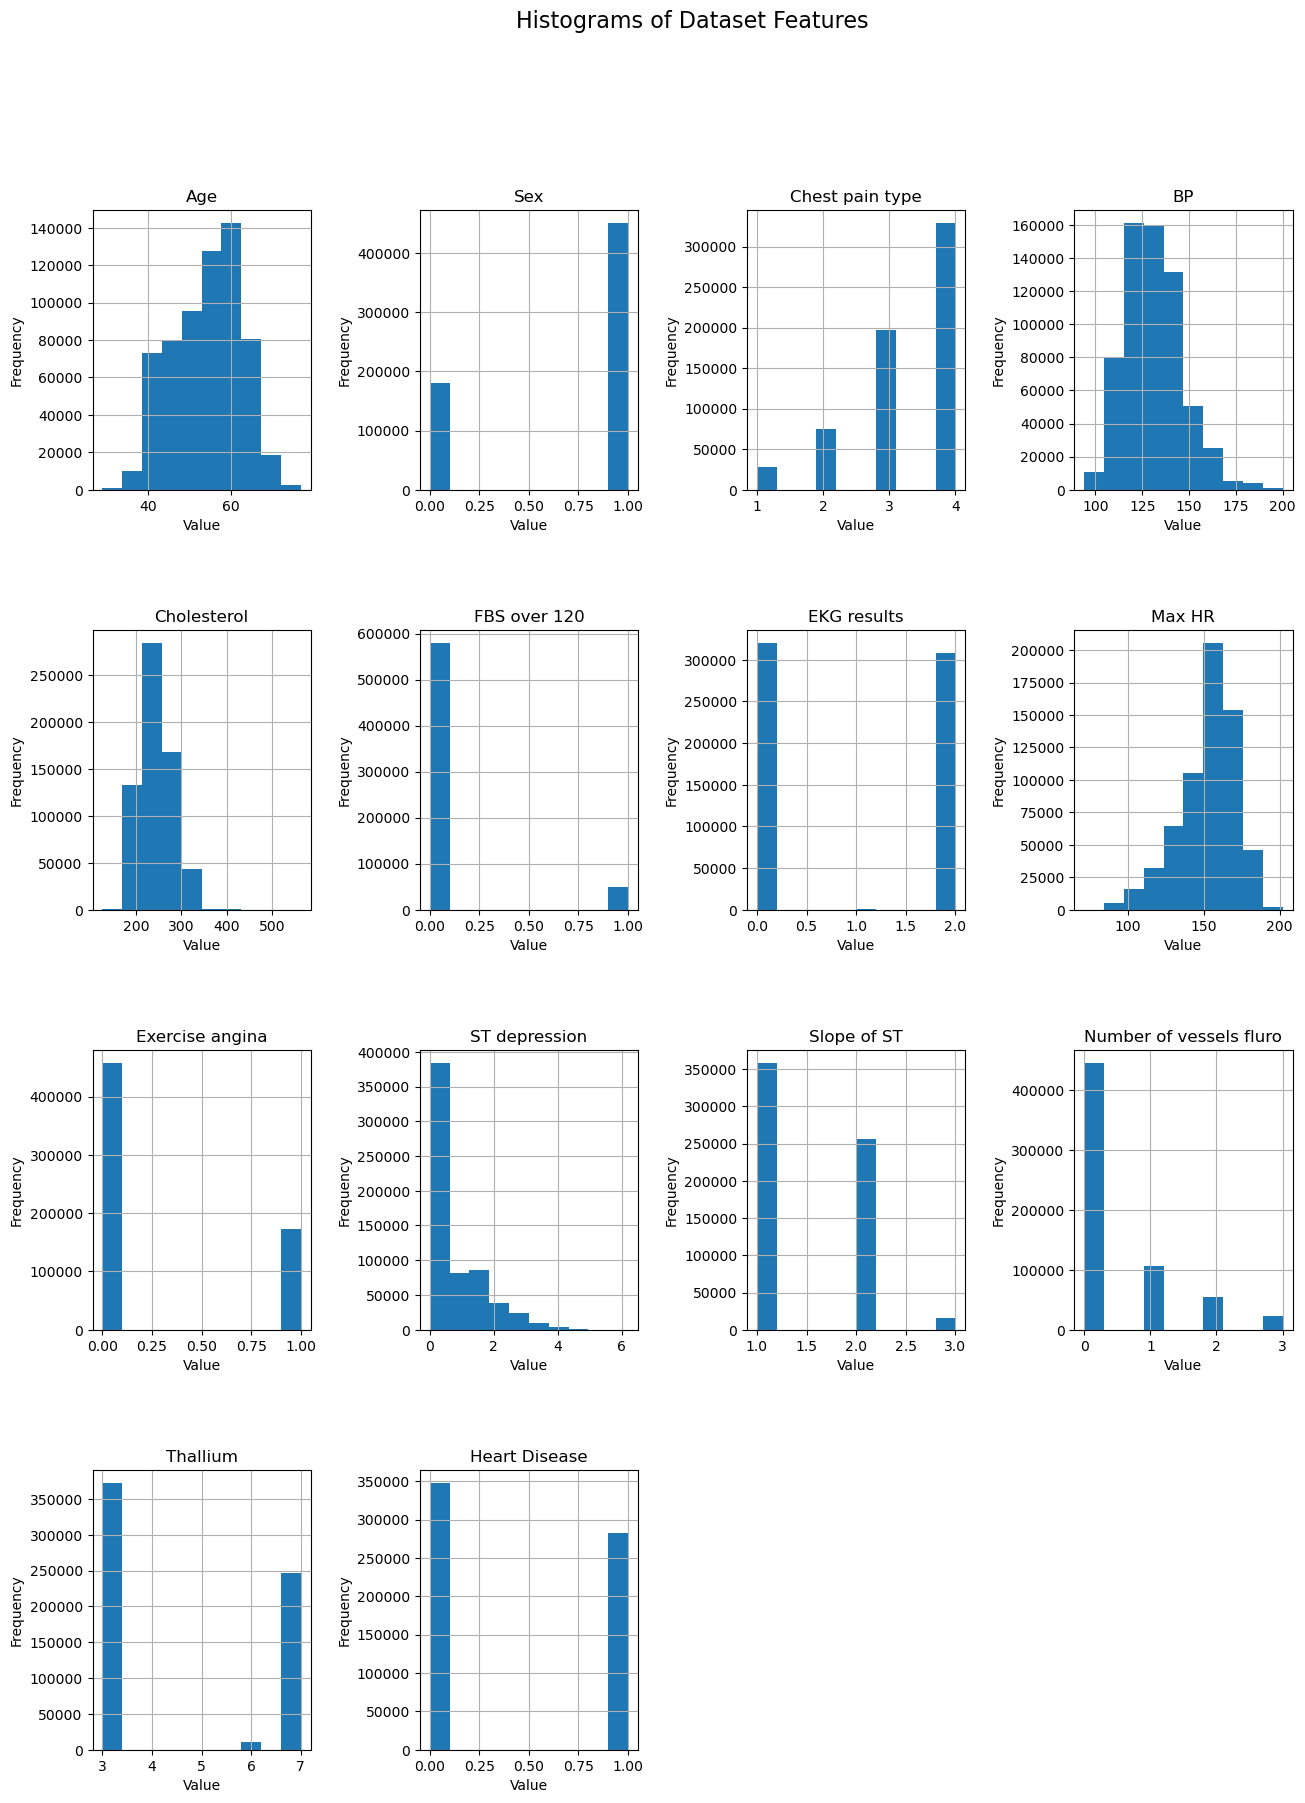

In [11]:
# Creation of histograms
fig, axes = plt.subplots(figsize=(15, 20))
ax = data.hist(ax=axes)

# Increasing spacing between plots
plt.subplots_adjust(hspace=0.5, wspace=0.5, left=0.1, right=0.9)  # wspace increases horizontal spacing

# Adding axis labels
for row in ax:
    for subplot in row:
        subplot.set_xlabel("Value")
        subplot.set_ylabel("Frequency")

# Adding a main title
plt.suptitle("Histograms of Dataset Features", fontsize=16)

plt.show()

Most features show reasonable distributions with some skewness in cholesterol, ST depression, and number of vessels, categorical variables are imbalanced (especially FBS, exercise angina, and chest pain types), age and max heart rate are approximately normally distributed, and the target variable is relatively balanced with a slight dominance of the absence class

## 1.3 Visualization and analysis of quantitative and categorical features.¶

In [12]:
# display basic statistical summary for dataset
pd.set_option('display.max_columns', None)
data.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873,0.448340
std,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007,0.497324
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000,0.000000
75%,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [13]:
categorical_disc_columns = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 
                            'Number of vessels fluro', 'Thallium', 'Heart Disease'
]

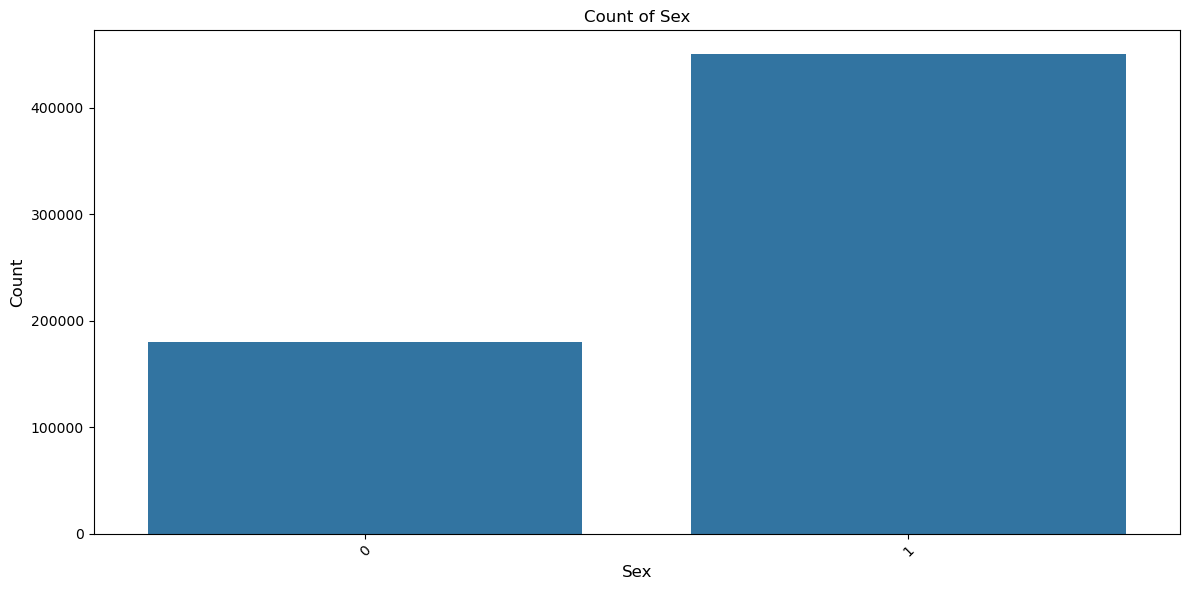

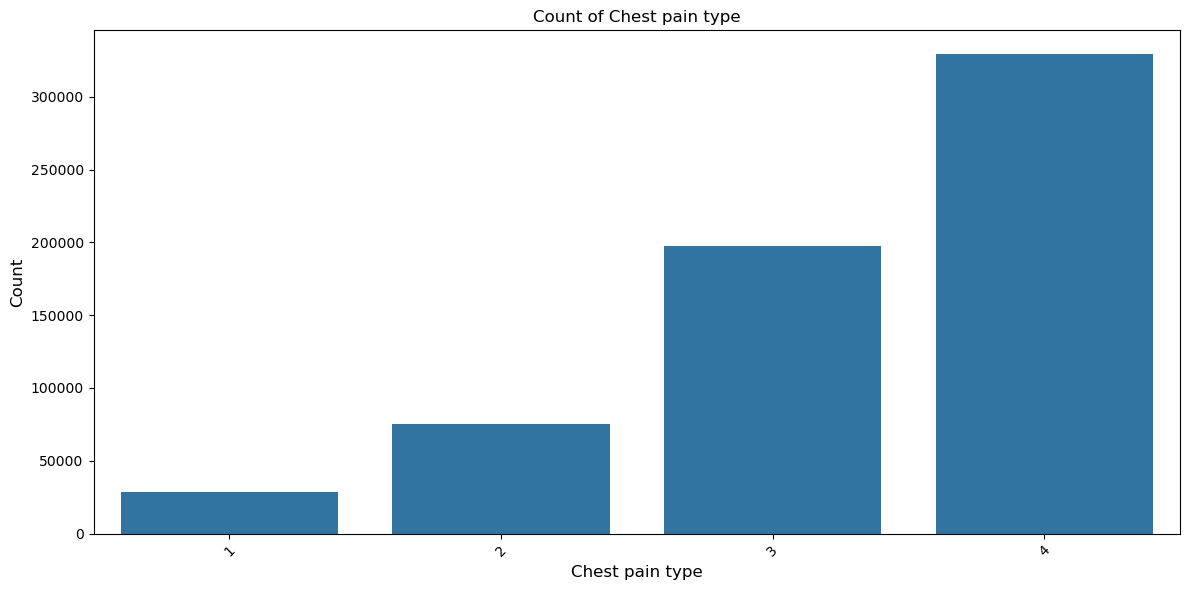

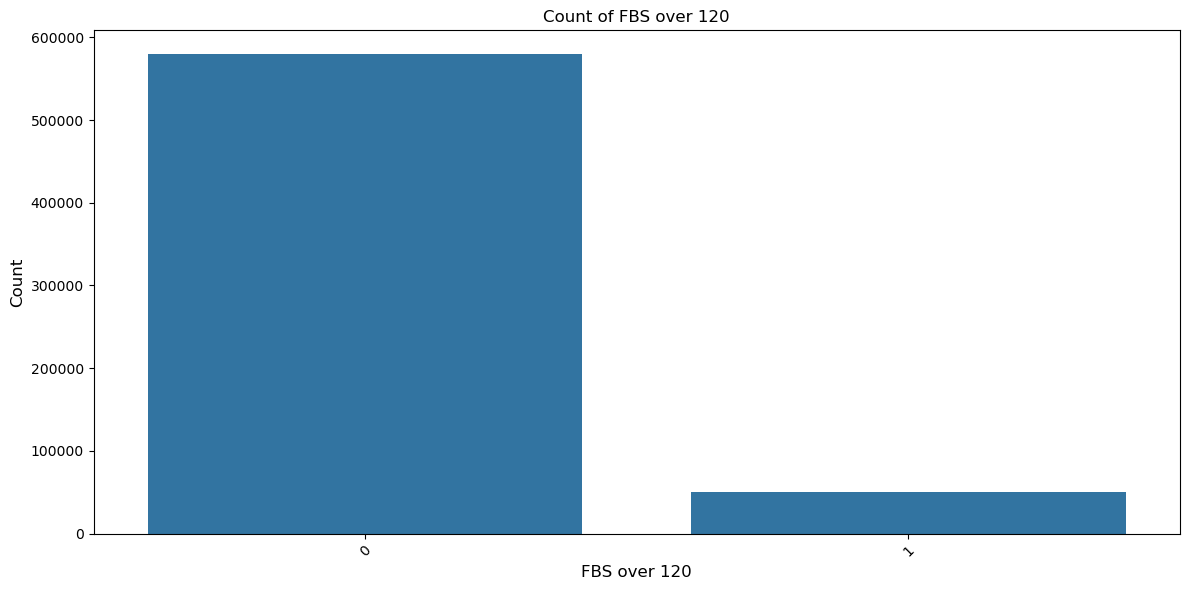

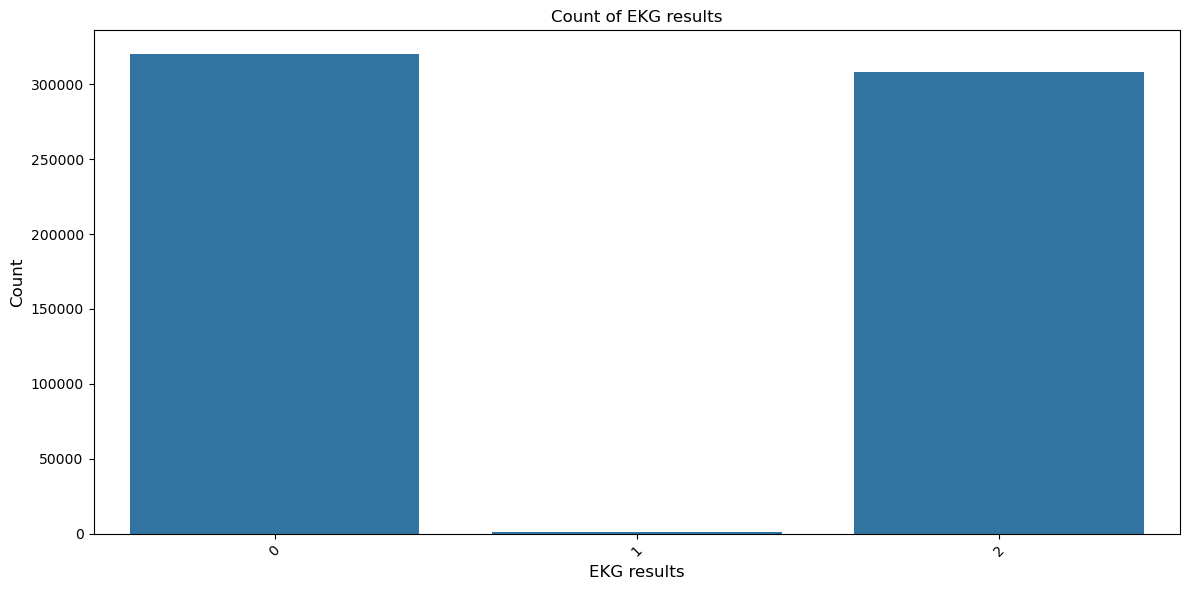

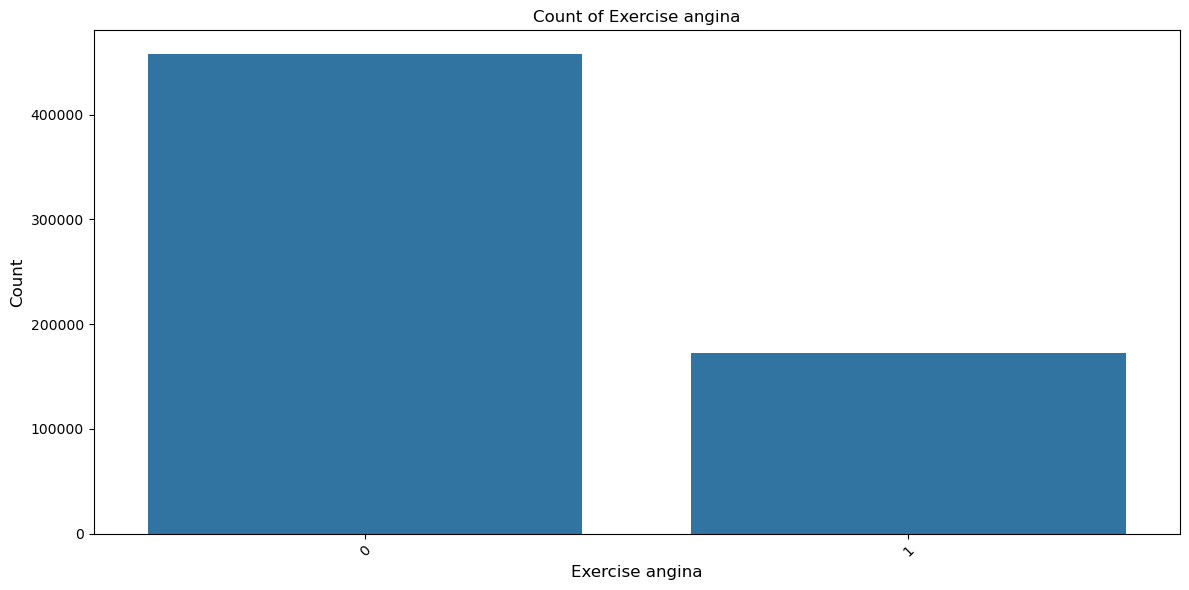

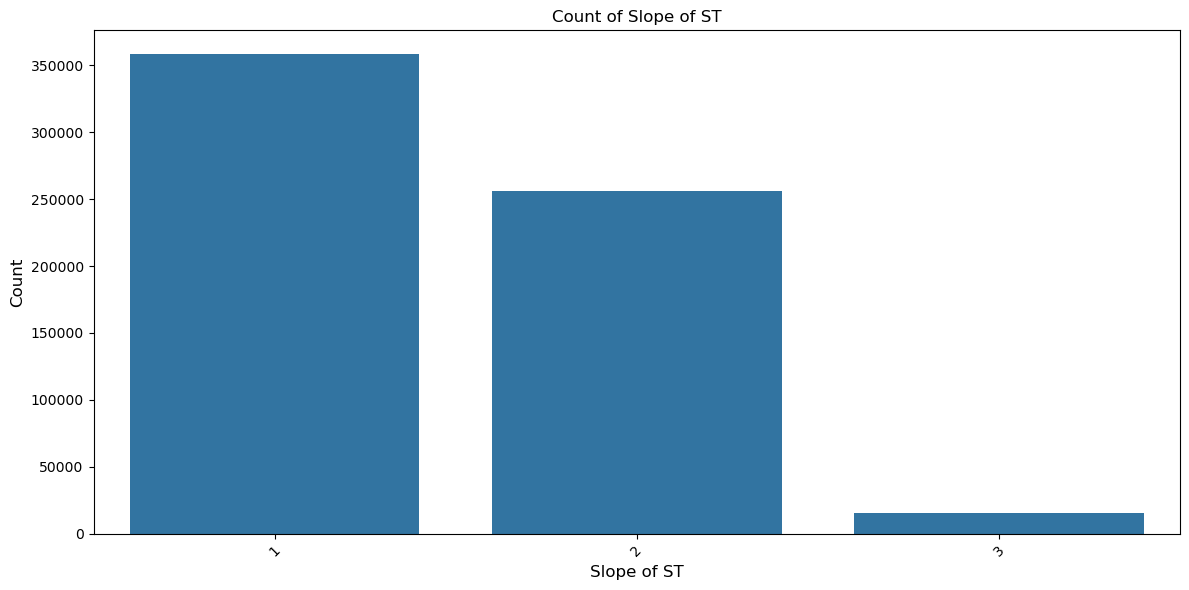

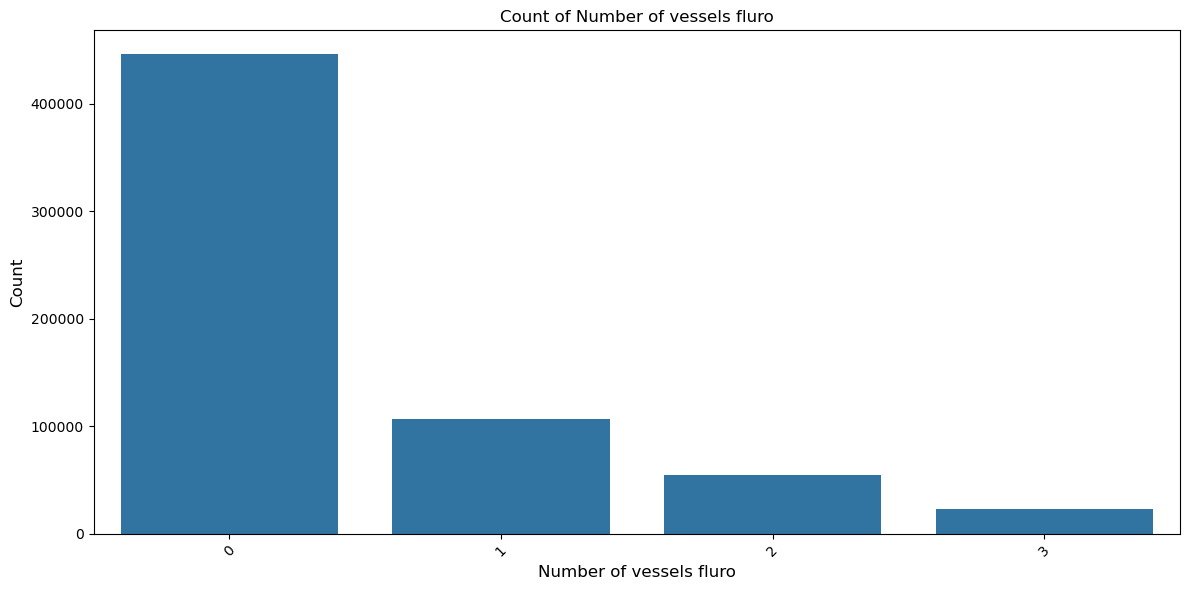

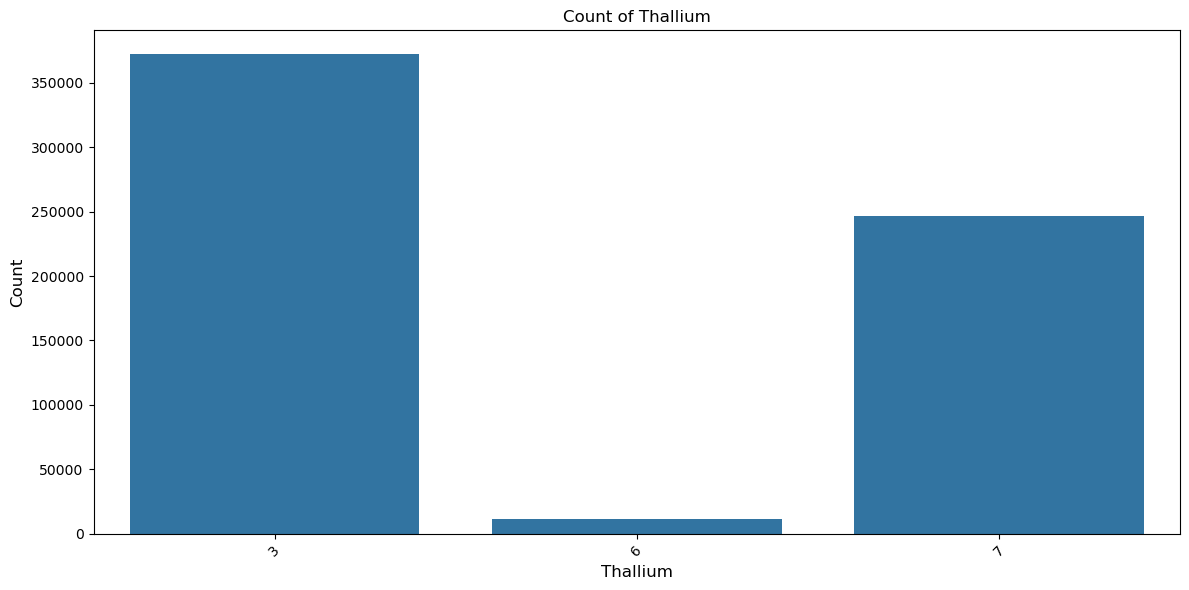

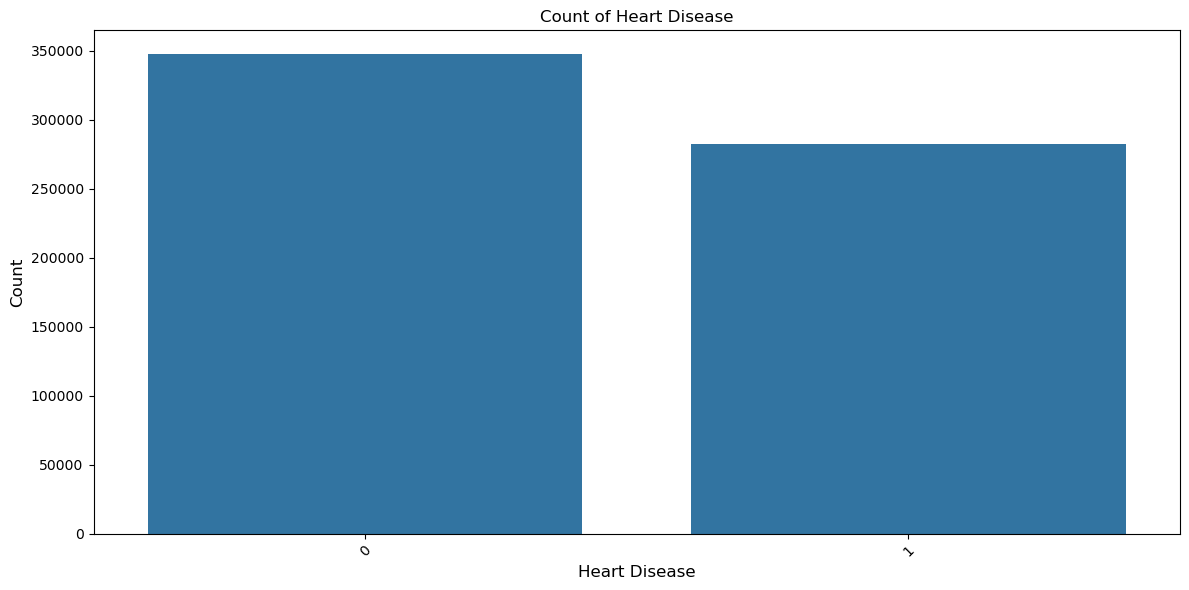

In [14]:
# Function to plot graphs for categorical data
for column in categorical_disc_columns:
    # Define the color palette with the desired colors
    plt.figure(figsize=(12, 6))
    sns.countplot(x=column, data=data)  
    plt.title(f'Count of {column}')  
    plt.xlabel(column, fontsize=12) 
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45, fontsize=10) 
    plt.yticks(fontsize=10)  
    plt.tight_layout()  
    plt.show()

the dataset shows stable central tendencies with age centered around mid-50s and relatively low variance, blood pressure and cholesterol fall within clinically expected ranges but cholesterol and ST depression exhibit right-skewness and potential outliers indicating extreme cases, max heart rate is approximately normally distributed, most categorical features are significantly imbalanced such as FBS (mostly 0), exercise angina (mostly absent), and number of vessels (mostly 0), chest pain type is dominated by higher categories suggesting more severe or typical angina patterns, slope of ST is mainly concentrated in lower values, thallium test shows two dominant categories with a small minority class, and the target variable is moderately imbalanced with a slightly higher proportion of patients without heart disease, which may require consideration during model training

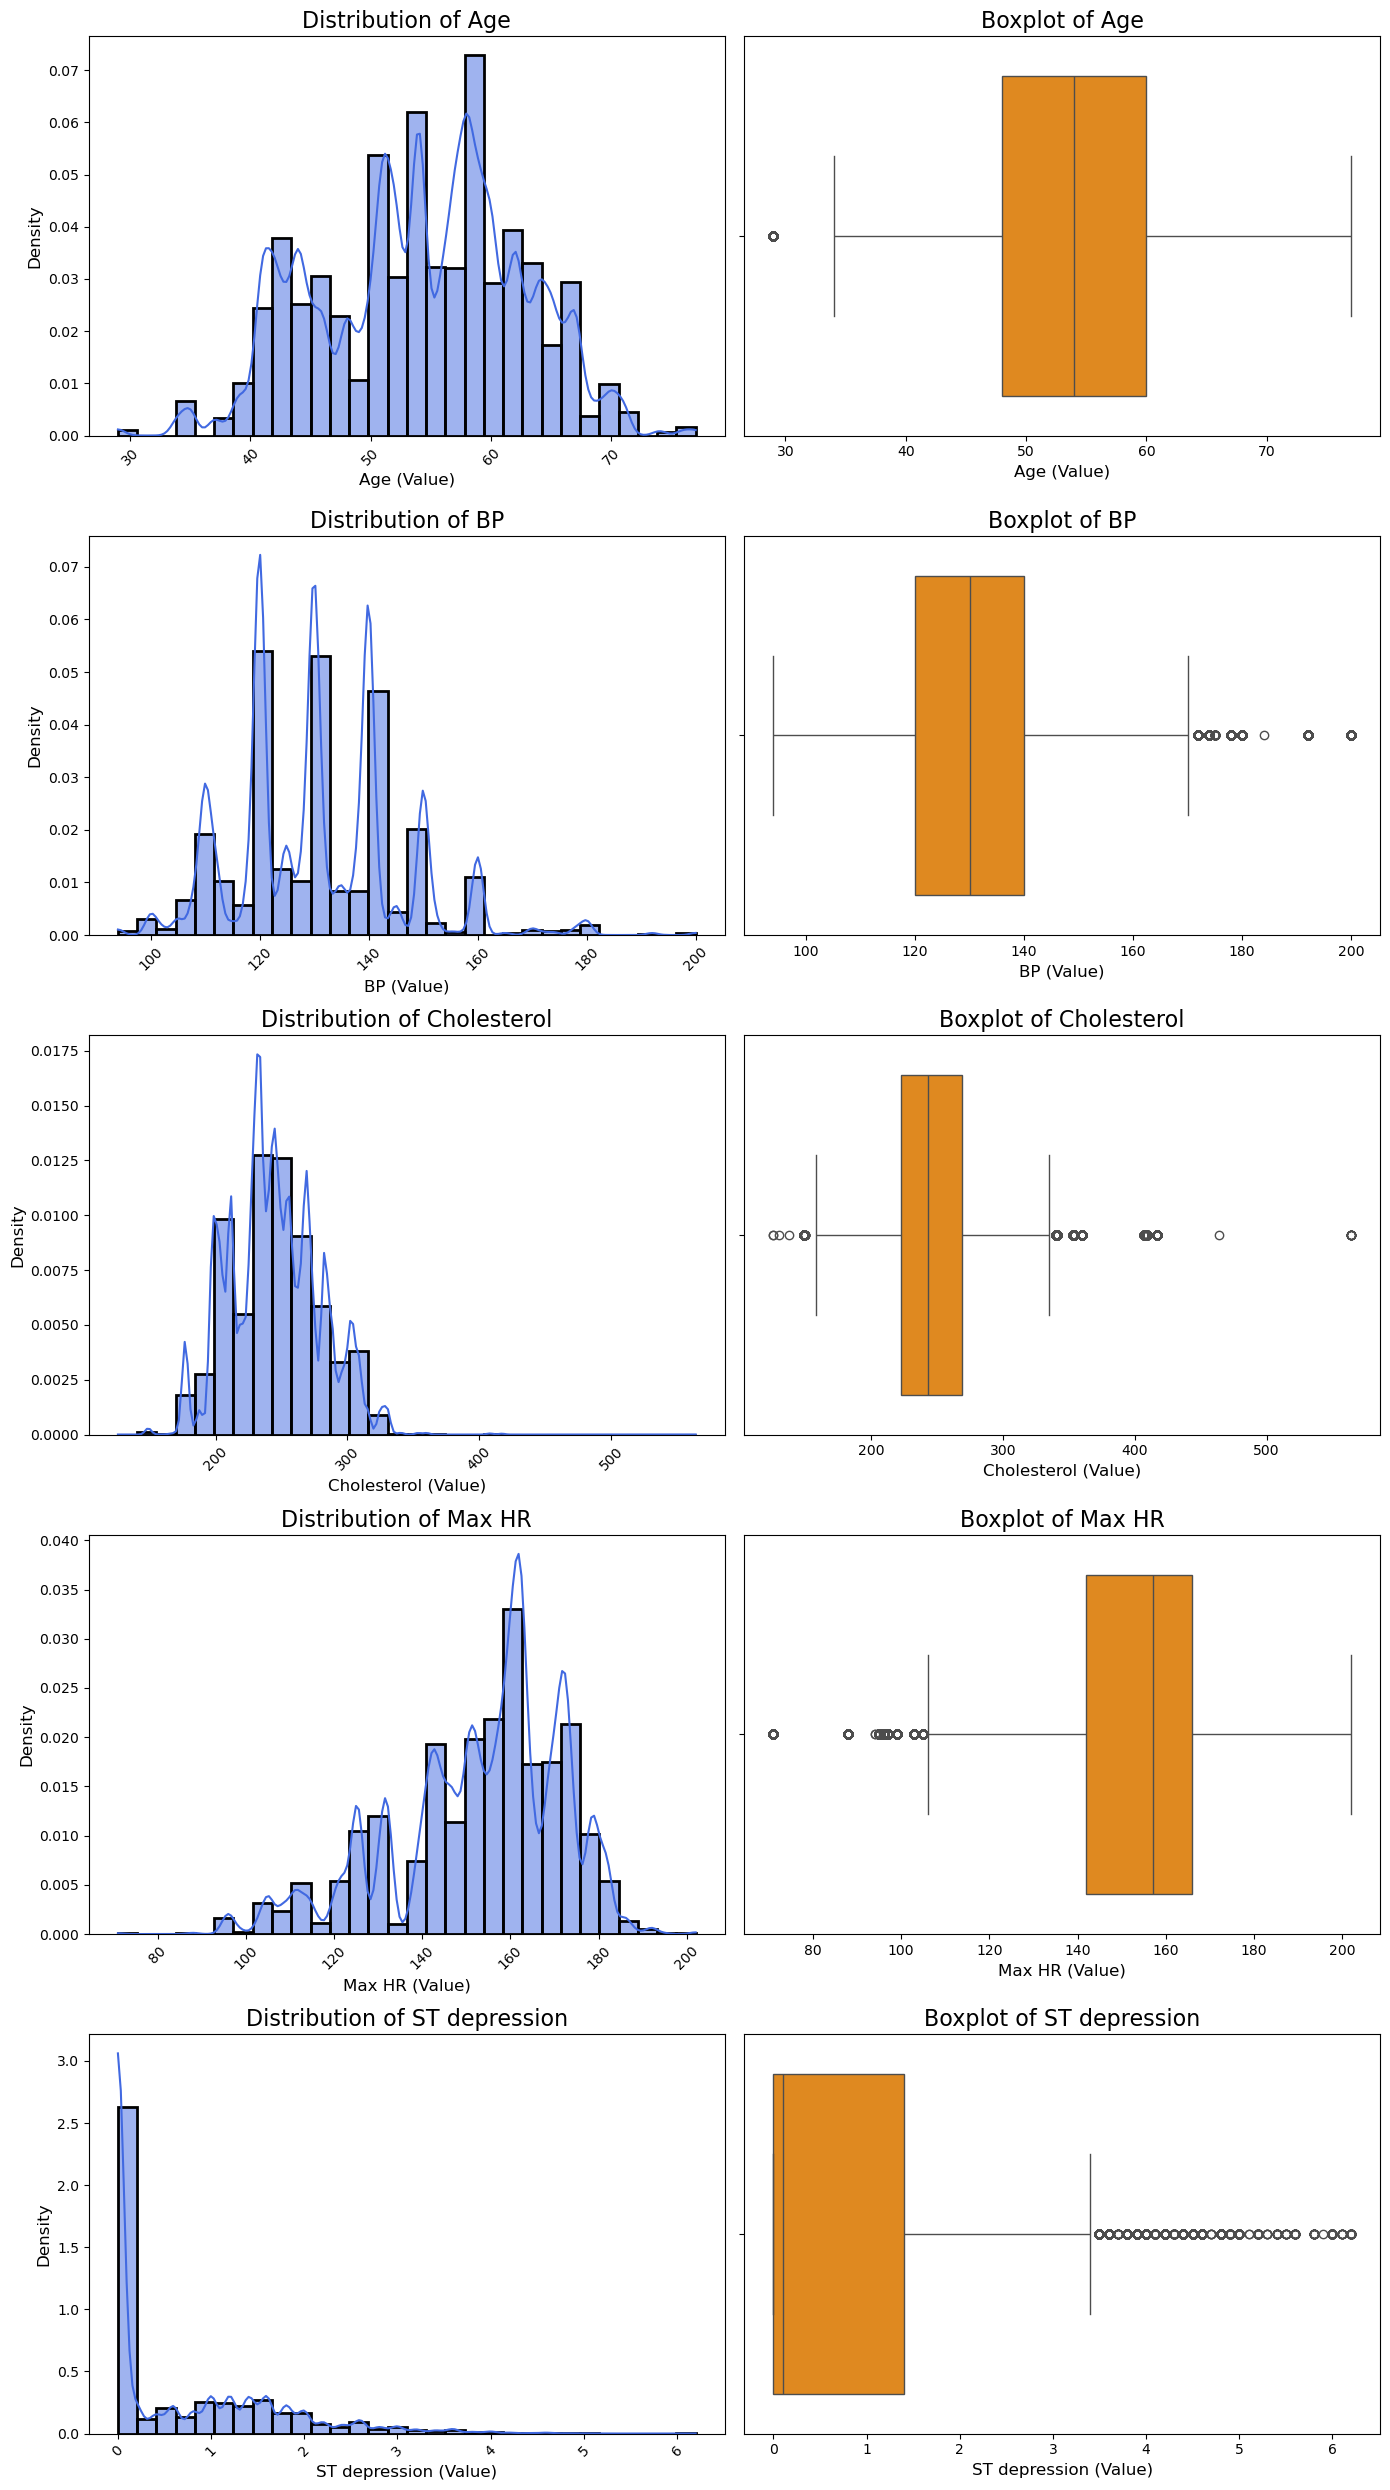

In [15]:
# Write function for building histograms for each quantitative feature
# First, let's specify the quantitative features
quantitative_columns = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
# Define the number of rows and columns for the subplots
num_features = len(quantitative_columns)
fig, axes = plt.subplots(nrows=num_features, ncols=2, figsize=(14, num_features * 5))

# Plot the graphs
for i, column in enumerate(quantitative_columns):
    # Plot the histogram with KDE
    sns.histplot(data[column], bins=30, kde=True, color='royalblue', ax=axes[i, 0], stat='density', linewidth=2)
    axes[i, 0].set_title(f'Distribution of {column}', fontsize=16)
    axes[i, 0].set_xlabel(f'{column} (Value)', fontsize=12)
    axes[i, 0].set_ylabel('Density', fontsize=12)
    axes[i, 0].tick_params(axis='x', rotation=45)
    
    # Plot the boxplot
    sns.boxplot(x=data[column], ax=axes[i, 1], color='darkorange')
    axes[i, 1].set_title(f'Boxplot of {column}', fontsize=16)
    axes[i, 1].set_xlabel(f'{column} (Value)', fontsize=12)

# Adjust layout
plt.tight_layout()
plt.show() 

the numerical feature analysis shows that age and max heart rate follow approximately normal distributions with moderate variability, while blood pressure and cholesterol exhibit right-skewness with several high-value outliers, ST depression is strongly right-skewed with most values concentrated near zero and a long tail of extreme cases, and boxplots confirm the presence of outliers particularly in cholesterol, BP, and ST depression, suggesting potential influence of extreme clinical observations but overall the features remain within realistic medical ranges and suitable for modeling

## 1.4 Correlation analysis

In [16]:
# Specify the list of continuous features
interval_cols = quantitative_columns

In [17]:
# Construct a correlation matrix, including categorical features, using phik_matrix()
data.phik_matrix(interval_cols=interval_cols) 

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
Age,1.000000,0.119279,0.124830,0.009403,0.021000,0.018216,0.070915,0.109407,0.147890,0.116950,0.122474,0.108332,0.183191,0.287607
Sex,0.119279,1.000000,0.333114,0.011205,0.042429,0.031860,0.056417,0.230006,0.298088,0.241527,0.106488,0.280332,0.167171,0.512339
Chest pain type,0.124830,0.333114,1.000000,0.014477,0.050195,0.040792,0.104298,0.240473,0.420813,0.264879,0.206517,0.400921,0.268579,0.731643
BP,0.009403,0.011205,0.014477,1.000000,0.005699,0.003981,0.010193,0.016506,0.018667,0.013763,0.016958,0.011686,0.022050,0.036464
Cholesterol,0.021000,0.042429,0.050195,0.005699,1.000000,0.005632,0.041977,0.042616,0.054267,0.039105,0.075154,0.050967,0.113372,0.093486
FBS over 120,0.018216,0.031860,0.040792,0.003981,0.005632,1.000000,0.009820,0.032131,0.043869,0.040707,0.018661,0.042115,0.019811,0.052662
EKG results,0.070915,0.056417,0.104298,0.010193,0.041977,0.009820,1.000000,0.148214,0.077716,0.176200,0.312670,0.103760,0.343233,0.132630
Max HR,0.109407,0.230006,0.240473,0.016506,0.042616,0.032131,0.148214,1.000000,0.307017,0.245967,0.244864,0.237268,0.339362,0.570756
Exercise angina,0.147890,0.298088,0.420813,0.018667,0.054267,0.043869,0.077716,0.307017,1.000000,0.371984,0.153811,0.425744,0.218150,0.639672
ST depression,0.116950,0.241527,0.264879,0.013763,0.039105,0.040707,0.176200,0.245967,0.371984,1.000000,0.474901,0.288796,0.354485,0.566341


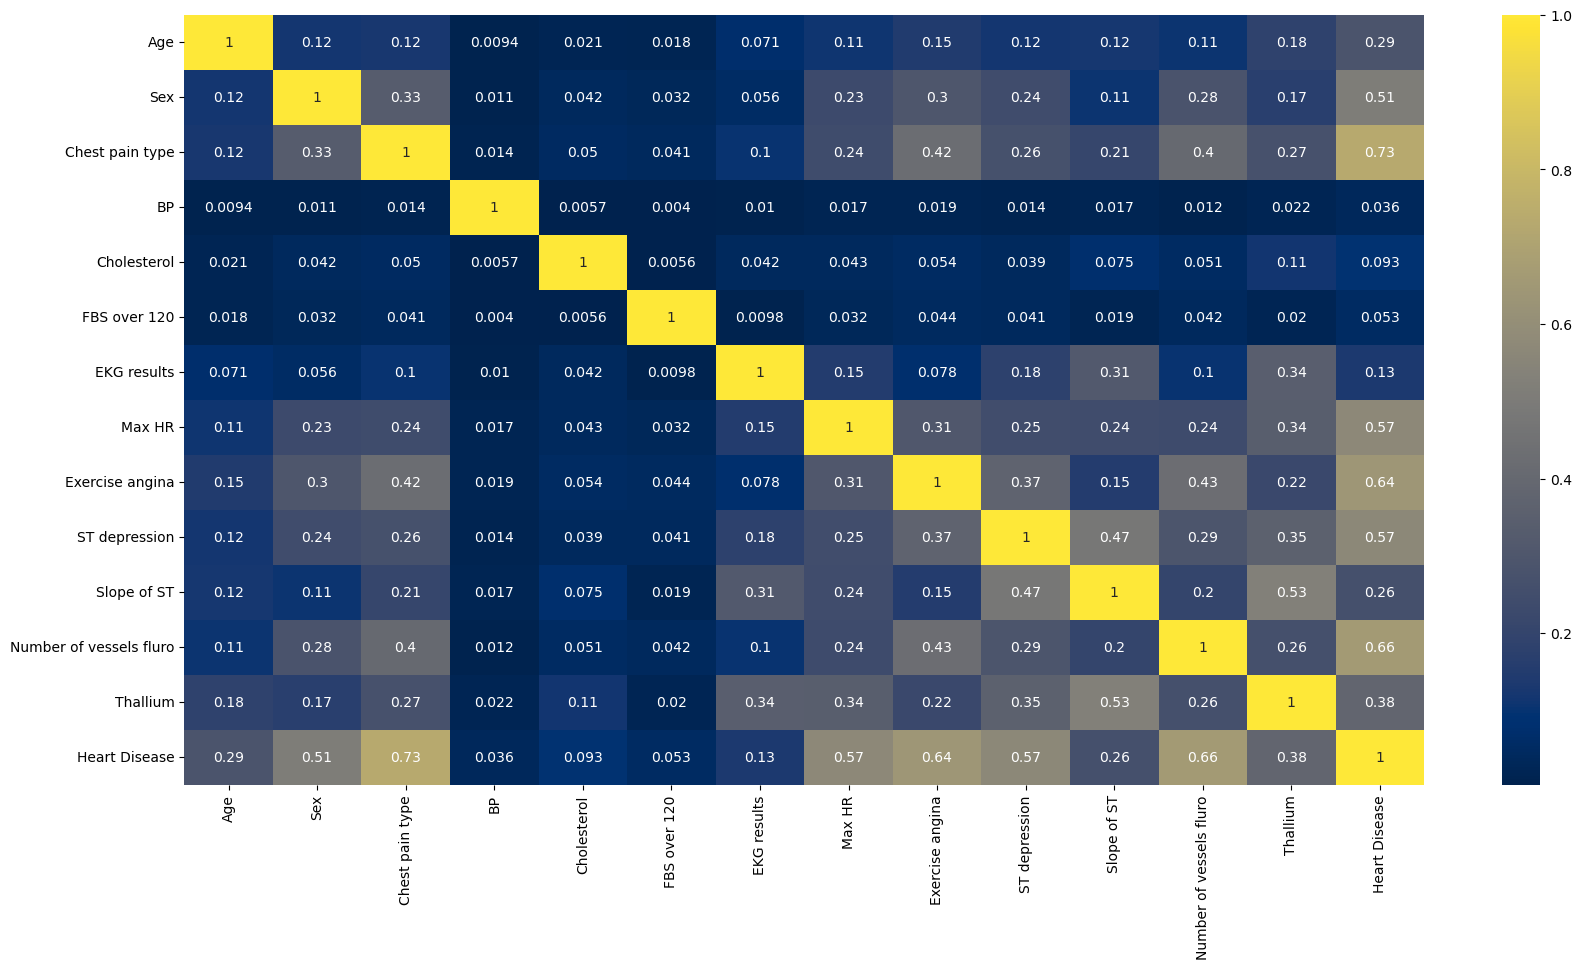

In [18]:
#Visualize the resulting correlation matrix
plt.figure(figsize=(20,10))
sns.heatmap(data.phik_matrix(interval_cols=interval_cols), annot=True, cmap='cividis');

the correlation analysis using the phik matrix shows that the strongest relationships with the target variable heart disease are observed for chest pain type (~0.73), number of vessels (~0.66), exercise angina (~0.64), ST depression (~0.57), and max heart rate (~0.57), indicating these features are the most informative predictors, sex also has a moderate correlation (~0.51) suggesting gender differences in disease occurrence, while thallium (~0.38) and age (~0.29) contribute moderately, most other features such as cholesterol, blood pressure, and FBS show weak correlations with the target implying limited predictive power individually, additionally there are noticeable inter-feature correlations such as between slope of ST and ST depression (~0.47), exercise angina and chest pain type (~0.42), and number of vessels with chest pain type (~0.40), which may indicate some redundancy or shared clinical patterns, overall the dataset contains several strong predictors without extreme multicollinearity, making it suitable for tree-based models and feature importance analysis.

In [19]:
# Select correlation with the target variable
# Calculate the Phik matrix
phik_corr_matrix = data.phik_matrix(interval_cols=interval_cols)

sale_price_corr = phik_corr_matrix['Heart Disease']

# Sort by descending importance
sorted_features = sale_price_corr.sort_values(ascending=False)

In [20]:
sorted_features 

Heart Disease              1.000000
Chest pain type            0.731643
Number of vessels fluro    0.660696
Exercise angina            0.639672
Max HR                     0.570756
ST depression              0.566341
Sex                        0.512339
Thallium                   0.382643
Age                        0.287607
Slope of ST                0.264441
EKG results                0.132630
Cholesterol                0.093486
FBS over 120               0.052662
BP                         0.036464
Name: Heart Disease, dtype: float64

the feature importance ranking based on phik correlation confirms that chest pain type is the most influential predictor of heart disease followed by number of vessels, exercise angina, max heart rate, and ST depression, all showing strong relationships with the target and representing key clinical indicators, sex also demonstrates a meaningful contribution suggesting gender-related differences, while thallium and age provide moderate predictive value, on the other hand features such as slope of ST, EKG results, cholesterol, FBS over 120, and especially blood pressure show weak correlations indicating limited individual impact on prediction, overall the results highlight a clear separation between highly informative clinical features and less relevant variables which can guide feature selection and model interpretation

## 2.Building models

In [21]:
# 1. SPLIT

RANDOM_STATE = 42
TEST_SIZE = 0.25

X = data.drop("Heart Disease", axis=1)
y = data["Heart Disease"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

# 2. FEATURE GROUPS


num_columns = [
    "Age",
    "BP",
    "Cholesterol",
    "Max HR",
    "ST depression"
]

cat_columns = [
    "Chest pain type",
    "EKG results",
    "Slope of ST",
    "Number of vessels fluro",
    "Thallium"
]

# 3. PREPROCESSOR

preprocessor = ColumnTransformer(
    transformers=[
        ("num",
         Pipeline([
             ("imputer", SimpleImputer(strategy="median")),
             ("scaler", StandardScaler())
         ]),
         num_columns),

        ("cat",
         Pipeline([
             ("imputer", SimpleImputer(strategy="most_frequent")),
             ("encoder", OneHotEncoder(
                 drop="first",
                 sparse_output=False,
                 handle_unknown="ignore"
             ))
         ]),
         cat_columns)
    ],
    remainder="passthrough"
)

# 4. MODELS


models = {
    "CatBoost": {
        "model": CatBoostClassifier(random_state=42, verbose=0),
        "params": {
            "model__iterations": [500, 1000],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__depth": [6, 8, 10],
            "model__l2_leaf_reg": [3, 5, 10],
        }
    },
    "RandomForest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "model__n_estimators": [200, 500],
            "model__max_depth": [10, 20, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
        }
    },
    "GradientBoosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "model__n_estimators": [200, 500],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__max_depth": [3, 5],
            "model__subsample": [0.8, 1.0],
        }
    }
}

# 5. HYPERPARAMETER SEARCH

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_models = {}

for name, config in models.items():

    print(f"Training {name}...")

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", config["model"])
    ])

    random_search = RandomizedSearchCV(
        pipe,
        param_distributions=config["params"],
        n_iter=15,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
        random_state=42
    )

    random_search.fit(X_train, y_train)

    best_models[name] = {
        "best_estimator": random_search.best_estimator_,
        "best_params": random_search.best_params_,
        "best_score": random_search.best_score_
    }

    print("Best ROC-AUC:", random_search.best_score_)
    print()

# 6. CHOOSE BEST MODEL

best_model_name = max(best_models, key=lambda x: best_models[x]["best_score"])
best_model = best_models[best_model_name]["best_estimator"]

print("Best overall model:", best_model_name)

# 7. VALIDATION EVALUATION

y_val_proba = best_model.predict_proba(X_val)[:, 1]
y_val_pred = best_model.predict(X_val)

print("VALID ROC-AUC:", roc_auc_score(y_val, y_val_proba))
print("VALID Accuracy:", accuracy_score(y_val, y_val_pred))
print("VALID F1:", f1_score(y_val, y_val_pred))

print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_val_pred))


# 8. FEATURE IMPORTANCE

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
importances = best_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\nTop 15 Features:\n")
print(importance_df.head(15))


Training CatBoost...
Best ROC-AUC: 0.9551838049942203

Training RandomForest...
Best ROC-AUC: 0.952012372546252

Training GradientBoosting...
Best ROC-AUC: 0.954979083731762

Best overall model: CatBoost
VALID ROC-AUC: 0.9557530424656269
VALID Accuracy: 0.8894095238095238
VALID F1: 0.8755626044836898

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.91      0.90     86887
           1       0.88      0.87      0.88     70613

    accuracy                           0.89    157500
   macro avg       0.89      0.89      0.89    157500
weighted avg       0.89      0.89      0.89    157500


Confusion Matrix:

[[78804  8083]
 [ 9335 61278]]

Top 15 Features:

                           feature  importance
3                      num__Max HR   19.861480
16                 cat__Thallium_7   17.571783
7           cat__Chest pain type_4   16.024430
19      remainder__Exercise angina    6.792638
4               num__ST depression    6.3

the CatBoost model achieved the best performance among the tested models with a high ROC-AUC of ~0.956 and balanced classification metrics (accuracy ~0.89, F1-score ~0.88), indicating strong predictive capability and good generalization, the confusion matrix shows a relatively low number of both false positives and false negatives suggesting reliable detection of both classes, feature importance analysis highlights max heart rate, thallium, chest pain type, exercise angina, ST depression, and number of vessels as the most influential predictors, which aligns with earlier correlation analysis and confirms the clinical relevance of these features, while variables such as cholesterol, blood pressure, and EKG results contribute less to the model, overall the model demonstrates robust performance with meaningful feature interpretability and no signs of severe class imbalance issues affecting results

In [22]:
test_predictions = best_model.predict_proba(test)[:, 1]

In [23]:
submission = pd.DataFrame({
    "id": test.index,
    "Heart Disease": test_predictions
})

submission.to_csv("submission.csv", index=False)


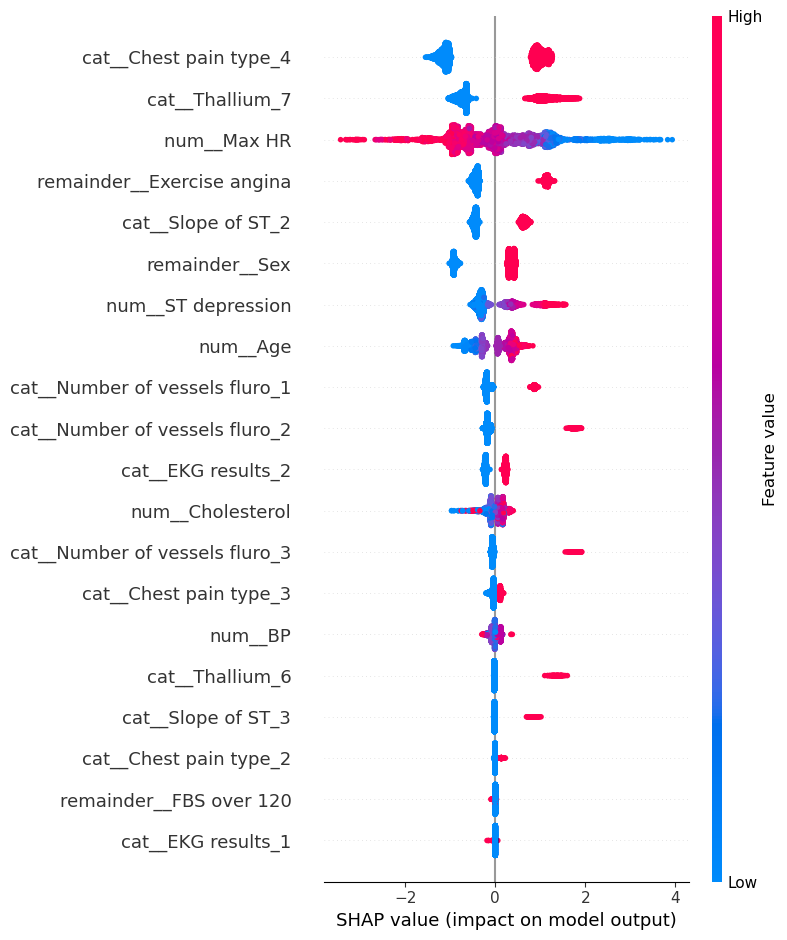

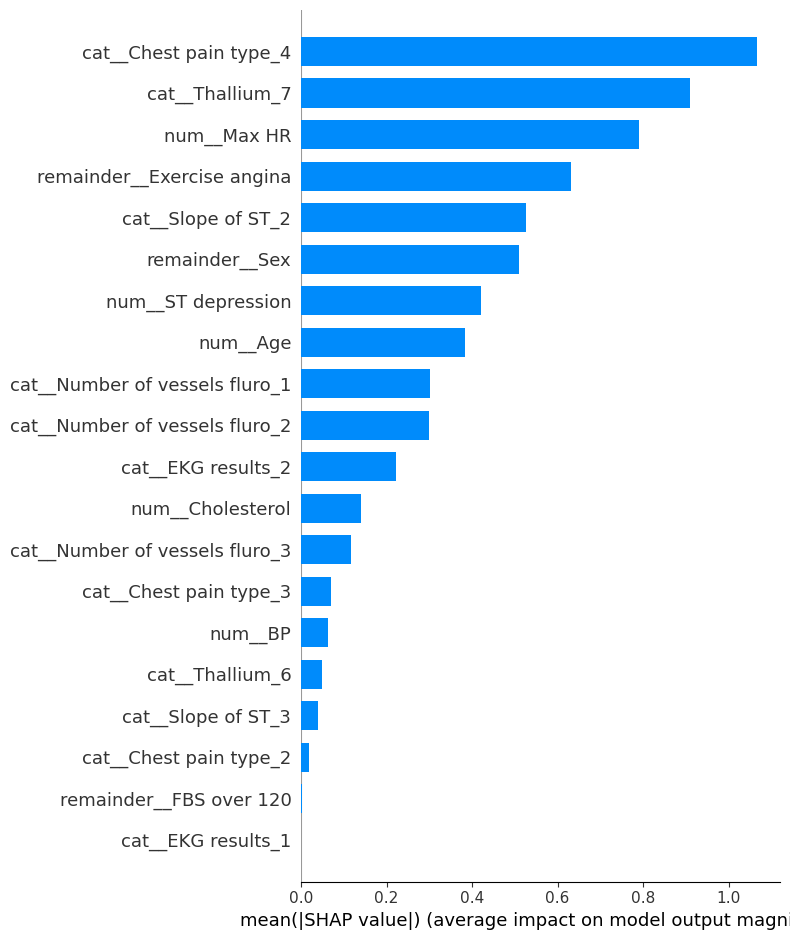

                           feature  mean_abs_shap
7           cat__Chest pain type_4       1.066985
16                 cat__Thallium_7       0.910952
3                      num__Max HR       0.790373
19      remainder__Exercise angina       0.630258
10              cat__Slope of ST_2       0.526761
17                  remainder__Sex       0.509440
4               num__ST depression       0.421929
0                         num__Age       0.383649
12  cat__Number of vessels fluro_1       0.301854
13  cat__Number of vessels fluro_2       0.300130
9               cat__EKG results_2       0.221715
2                 num__Cholesterol       0.140457
14  cat__Number of vessels fluro_3       0.116879
6           cat__Chest pain type_3       0.070773
1                          num__BP       0.062031


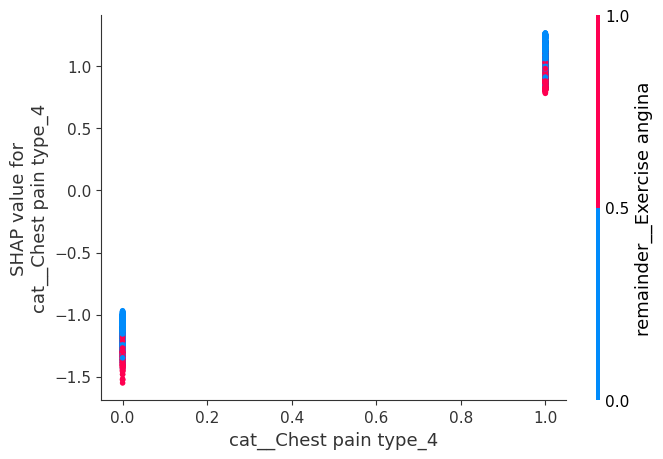

In [24]:
# SHAP ONLY FOR THE BEST CATBOOST MODEL

import matplotlib.pyplot as plt

# transformed validation data
X_val_transformed = best_model.named_steps["preprocessor"].transform(X_val)
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

X_val_transformed_df = pd.DataFrame(
    X_val_transformed,
    columns=feature_names,
    index=X_val.index
)

# sample for speed
X_shap = X_val_transformed_df.sample(min(5000, len(X_val_transformed_df)), random_state=42)

cat_model = best_model.named_steps["model"]

explainer = shap.TreeExplainer(cat_model)
shap_values = explainer.shap_values(X_shap)

# for binary classification
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# summary beeswarm plot
shap.summary_plot(shap_values, X_shap)

# bar plot
shap.summary_plot(shap_values, X_shap, plot_type="bar")

# importance table
shap_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

print(shap_importance.head(15))

# dependence plot for the top feature
top_feature = shap_importance.iloc[0]["feature"]
shap.dependence_plot(top_feature, shap_values, X_shap)

the shap analysis confirms that the most influential features driving the model predictions are chest pain type 4, thallium level 7, max heart rate, exercise angina, and slope of ST, where higher values of chest pain severity, abnormal thallium results, presence of exercise angina, and increased ST depression positively contribute to predicting heart disease while higher max heart rate tends to have an inverse effect reducing predicted risk, age and sex show moderate contributions with older age and male sex increasing risk, features such as number of vessels also contribute meaningfully especially higher vessel counts, while cholesterol, blood pressure, FBS, and some EKG categories have relatively low impact on the model output, overall the shap distribution plots demonstrate consistent and stable feature effects without extreme variability, indicating a robust and interpretable model where key clinical indicators align with domain knowledge and earlier correlation analysis confirming that the model relies on medically relevant patterns rather than noise